
 Recorded Time: 4.9991106510162355


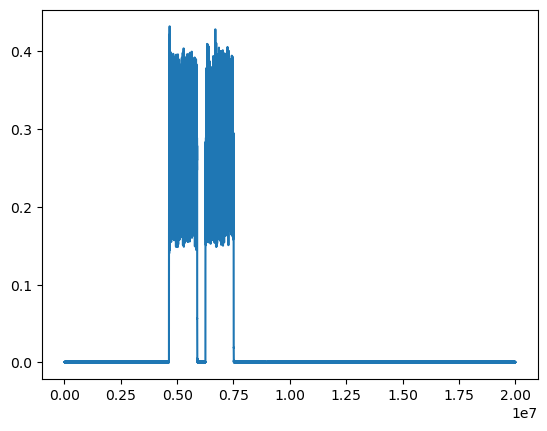

Number of zeros: 17485813

number of frames: 6
# Frame OK ...

file size is: 20097800
Size OK .
Testing receive rate at Fc: 2.500 GHz and Fs: 4 Msps on 1 channels.

Done!


In [47]:
import uhd, os, time
import numpy as np
import sys

mimo = False
samps_per_packet = 1950
file_name = "test"

acq_time = 5 # in second

Fc = 2.5e9# Hz
Fs = 4e6 
gain = 0.0 # dBs

THRESHOLD = 0.01
# THRESHOLD = 0

inChamber = False


# Santizing Check param the recorded file size and number of frames
minSize = 1e3
maxSize = 99.99e6
minFrames = 2
maxFrames = 40

minFrameSize = 10


if mimo: 
    chnls = [0,1]
else:
    chnls = [0]

args = "serial=8000182"
usrp = uhd.usrp.MultiUSRP(args=args)
# uhd.usrp.SubdevSpec("0:A  1:D")



# this might change later due to wrong Fc or Fs selection and actual value will be replaced
file = file_name + "_"+str(np.round(Fc,2))+"_"+str(np.round(Fs,2))+"_"+str(gain)+"_"+str(acq_time) + "_"+ str(inChamber)+"_.iq"

def _config_streamer(usrp,chnls,spp = None):
    st_args = uhd.usrp.StreamArgs("fc32", "sc16")
    st_args.channels = chnls
    # st_args.args = "spp="+str(spp)
    streamer = usrp.get_rx_stream(st_args)

    return streamer

def _batch_init(streamer,batch_size = None):
    if batch_size is None:
        batch_size = streamer.get_max_num_samps()
    nr_batches= int(acq_time * Fs / batch_size)
    return batch_size, nr_batches

def _start_stream(streamer,batch_size):
    stream_cmd = uhd.types.StreamCMD(uhd.types.StreamMode.start_cont)
    stream_cmd.num_samps = batch_size
    stream_cmd.stream_now = False  
    stream_cmd.time_spec = uhd.types.TimeSpec(usrp.get_time_now().get_real_secs() + 0.05)   
    streamer.issue_stream_cmd(stream_cmd)

def _stop_stream(streamer,recv_buffer):
    metadata = uhd.types.RXMetadata()
    stream_cmd = uhd.types.StreamCMD(uhd.types.StreamMode.stop_cont)
    streamer.issue_stream_cmd(stream_cmd)
    while streamer.recv(recv_buffer, metadata):
        pass



# %%


usrp.set_time_now(uhd.types.TimeSpec(0.0)) # this should work well for syncing the MIMO channel

streamer = _config_streamer(usrp=usrp, chnls=chnls,spp=None)
batch_size, nr_batches = _batch_init(streamer=  streamer, batch_size= None)
recv_buffer = np.zeros((len(chnls), batch_size), dtype=np.complex64)
metadata = uhd.types.RXMetadata()

for chnl in chnls:
    usrp.set_rx_rate(Fs, chnl)
    usrp.set_rx_freq(uhd.libpyuhd.types.tune_request(Fc), chnl)
    usrp.set_rx_gain(gain, chnl)

# usrp.set_rx_agc(False, 0)

_start_stream(streamer = streamer,batch_size= batch_size)

#updating file name if mimo
if mimo:
    file1 = file_name + "_"+str(usrp.get_rx_freq())+"_"+str(usrp.get_rx_rate())+"_"+str(gain)+"_"+str(acq_time) + "_"+ str(inChamber)+"_1.iq"
    file2 = file_name + "_"+str(usrp.get_rx_freq())+"_"+str(usrp.get_rx_rate())+"_"+str(gain)+"_"+str(acq_time) + "_"+ str(inChamber)+"_2.iq"
    f1 = open(file1,"wb")
    f2 = open(file2,"wb")

    start = time.time()
    for i in range(nr_batches):
        streamer.recv(recv_buffer, metadata)
        # np.zeros(1).tofile(f)
        recv_buffer[0].tofile(f1)
        recv_buffer[1].tofile(f2)
    duration = time.time() - start
    print("\n Recorded Time: " + str(duration-0.05))
    # Stop Stream
    _stop_stream(streamer=streamer, recv_buffer=recv_buffer)
    f1.close()
    f2.close()

else:
    file = file_name + "_"+str(usrp.get_rx_freq())+"_"+str(usrp.get_rx_rate())+"_"+str(gain)+"_"+str(acq_time) + "_"+ str(inChamber)+"_.iq"
    f = open(file,"wb")

    start = time.time()
    for i in range(nr_batches):
        streamer.recv(recv_buffer, metadata)
        # np.zeros(1).tofile(f)
        recv_buffer[0].tofile(f)
    duration = time.time() - start
    print("\n Recorded Time: " + str(duration-0.05))
    # Stop Stream
    _stop_stream(streamer=streamer, recv_buffer=recv_buffer)
    f.close()



# %%
import dataProcessing 
import matplotlib.pyplot as plt
utills = dataProcessing.Utills()

# %%

samples = None
def file_santizer(file, minSize = 30e6,maxSize = 1e9,minFrames = 100,maxFrames = 1000,THRESHOLD = THRESHOLD, minFrameSize = 1): 
    global samples
    if THRESHOLD != 0:
        samples = np.fromfile(file, np.complex64) # Read in file.  We have to tell it what format it is
        plt.plot(np.abs(samples))
        plt.show()  
        zeros = np.abs(samples)<THRESHOLD
        print("Number of zeros: " + str(np.sum(zeros)))
        samples[zeros] = 0
        framesIndex = utills.frameFinder(samples, minFrameSize=minFrameSize)
        utills.zeroRemover(file = file, samples=samples,framesIndex=framesIndex)     

        #check minimum number of the frames
        nr_frame = len(framesIndex)
        print("\nnumber of frames: " + str(nr_frame))
        if  nr_frame < minFrames or  nr_frame > maxFrames:
            print("# Frame check failed ...")
        else:
            print("# Frame OK ...")


    # Check the file size
    size = os.path.getsize(file)
    print("\nfile size is: " + str(os.path.getsize(file)))
    if size < minSize or size > maxSize:
        print("Size check failed ...    ")
    else:
        print("Size OK .")




### tests

if mimo:
    file_santizer(file=file1,minSize = minSize,maxSize = maxSize,minFrames = minFrames,maxFrames = maxFrames, minFrameSize= minFrameSize)
    file_santizer(file=file2,minSize = minSize,maxSize = maxSize,minFrames = minFrames,maxFrames = maxFrames, minFrameSize= minFrameSize)
else:
    file_santizer(file=file,minSize = minSize,maxSize = maxSize,minFrames = minFrames,maxFrames = maxFrames, minFrameSize= minFrameSize)

print("Testing receive rate at Fc: {:.3f} GHz and Fs: {:.0f} Msps on {:d} channels.".format(
    usrp.get_rx_freq()/1e9, usrp.get_rx_rate()/1e6, streamer.get_num_channels()))
print("\nDone!")


File name has a correct format!


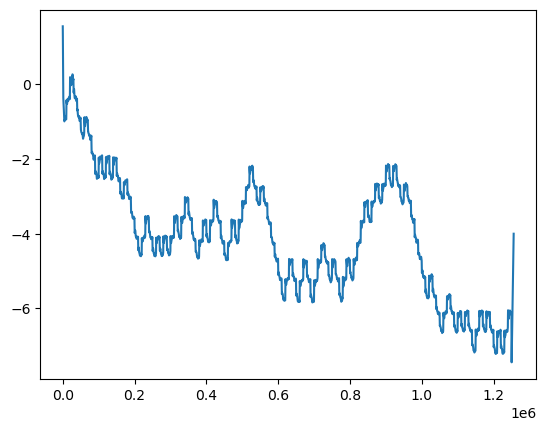

In [91]:
import dataProcessing 
import matplotlib.pyplot as plt
utills = dataProcessing.Utills()
IQdata, tindx = utills.readFile(file="test_2500000000.0_4000000.0_0.0_5_False_.iq")



# utills.plotter(IQdata = IQdata, tindx = tindx, batch= 1, frameShowLimit=-1, compression_ratio= 1, fft=0)
# plt.plot(np.abs(IQdata.frameByNumber(1)))
plt.show()
frame= IQdata.frameByNumber(0)
frame = frame * np.exp(2j*np.pi*124.5*np.linspace(0,len(frame),len(frame))/len(frame))

plt.plot(IQdata.unwrapPhase(IQdata.phase(IQdata.filter(frame, 1000))))



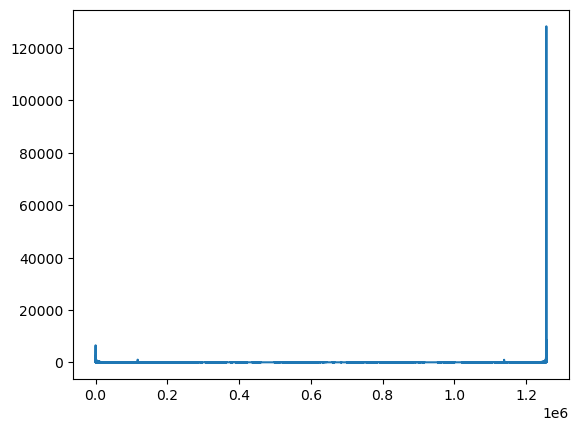

In [40]:
plt.plot(np.abs(np.fft.fft(IQdata.samples)))

In [3]:



def gaussian_filter(num_taps, bt, sps):
    """
    Generate Gaussian filter for GFSK.
    """
    t = np.linspace(-num_taps//2, num_taps//2, num_taps, endpoint=False) / sps
    h = np.exp(-0.5 * (t * np.pi * bt)**2)
    h /= np.sqrt(np.sum(h**2))  # Normalize
    return h.astype(np.float32)

def gardner_timing_recovery(samples, sps, loop_gain=0.01, damping=1.0):
    """
    Simple Gardner timing recovery (conceptual).
    - samples: matched-filtered baseband signal, oversampled by 'sps'
    - sps: nominal samples per symbol
    - loop_gain, damping: loop parameters (very sensitive!)

    Returns an array of symbol-spaced samples.
    """
    # We'll store the recovered samples here
    out = []
    # mu: fractional offset in [0, sps)
    mu = 0.0

    # Loop constants (very approximate)
    alpha = loop_gain
    beta = alpha**2 / damping

    i = 0
    while i + sps < len(samples):
        # Interpolate to get the current sample
        sample = samples[min(len(samples)-1,int(i + mu))]
        out.append(sample)

        # Gardner error calculation
        # e = (y(nT + mu - T/2) - y(nT + mu + T/2)) * y(nT + mu)
        # Simplified for GFSK
        if i + int(mu + sps//2) < len(samples) and i + int(mu - sps//2) >= 0:
            y_prev = samples[min(len(samples)-1,int(i + mu - sps//2))]
            y_next = samples[min(len(samples)-1,int(i + mu + sps//2))]
            e = (np.real(y_prev) - np.real(y_next)) * np.real(sample)
            # Update timing error
            mu += sps + beta * e
        else:
            mu += sps

        i = int(mu)

    return np.array(out, dtype=np.complex64)

def frequency_demodulate(samples, sample_rate, sps):
    """
    Perform frequency demodulation on complex baseband samples.
    Returns the instantaneous frequency deviation.
    """
    # Calculate the phase difference
    phase = np.angle(samples)
    phase_diff = np.diff(phase)
    # Wrap phase to [-pi, pi]
    phase_diff = np.unwrap(phase_diff)
    # Instantaneous frequency
    inst_freq = (phase_diff / (2.0 * np.pi)) * sample_rate
    # Downsample to symbol rate
    inst_freq = inst_freq[::sps]
    return inst_freq

def bits_to_string(bit_list):
    """
    Convert list/array of bits to ASCII string (8-bit, MSB first).
    """
    chars = []
    for i in range(0, len(bit_list), 8):
        byte_bits = bit_list[i:i+8]
        if len(byte_bits) < 8:
            break
        val = 0
        for b in byte_bits:
            val = (val << 1) | b
        chars.append(chr(val))
    return "".join(chars)

#------------------------------------
# 5. Matched filter (Gaussian)
#------------------------------------
gf = gaussian_filter(NUM_TAPS, BT, SPS)
filtered = signal.lfilter(gf, 1.0, recv_buffer[:total_recvd])

plt.figure(figsize=(12, 6))
plt.plot(filtered)
plt.title("Matched Filter Output")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()

#------------------------------------
# 6. Frequency Demodulation
#------------------------------------
# Assuming RX_RATE = symbol_rate * sps
symbol_rate = RX_RATE / SPS
freq_deviation = frequency_demodulate(filtered, RX_RATE, SPS)

plt.figure(figsize=(12, 6))
plt.plot(freq_deviation)
plt.title("Frequency Demodulated Signal")
plt.xlabel("Symbol Index")
plt.ylabel("Frequency Deviation (Hz)")
plt.show()

#------------------------------------
# 7. Timing Recovery (Gardner)
#------------------------------------
# Normalize frequency deviation
freq_deviation_norm = freq_deviation / np.max(np.abs(freq_deviation))
symbol_aligned = gardner_timing_recovery(freq_deviation_norm, 1, loop_gain=0.005, damping=1.0)
# Note: Since frequency demodulation already reduces to symbol rate, sps=1

plt.figure(figsize=(12, 6))
plt.plot(symbol_aligned)
plt.title("Symbol Aligned Frequency Deviation")
plt.xlabel("Symbol Index")
plt.ylabel("Normalized Frequency Deviation")
plt.show()

#------------------------------------
# 8. Frame Sync (Preamble Correlation)
#------------------------------------
# We'll perform correlation with the known preamble bits.
# For GFSK, preamble bits are mapped to frequency shifts.
preamble_bits = np.array(PREAMBLE, dtype=np.uint8)
# Map bits to frequency shifts: '1' -> +1, '0' -> -1
preamble_syms = np.where(preamble_bits == 1, 1.0, -1.0).astype(np.float32)

# Cross-correlate with the symbol-aligned frequency deviations
corr = np.correlate(symbol_aligned, preamble_syms, mode='valid')
start_idx = np.argmax(np.abs(corr)) + len(preamble_syms)//2  # approximate location of preamble

print(f"[RX] Frame sync: best correlation at symbol index {start_idx}")

#------------------------------------
# 9. Hard Decision Demod
#------------------------------------
# Slice out the payload after the preamble
payload_syms = symbol_aligned[start_idx + len(preamble_syms):]
# Decision: positive frequency deviation => bit=1, else bit=0
rx_bits = (payload_syms > 0).astype(np.uint8)

#------------------------------------
# 10. Convert bits -> ASCII
#------------------------------------
decoded_msg = bits_to_string(rx_bits)
print("[RX] Decoded message (ASCII):")
print(decoded_msg)

print("[RX] Done.")



NameError: name 'NUM_TAPS' is not defined